In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


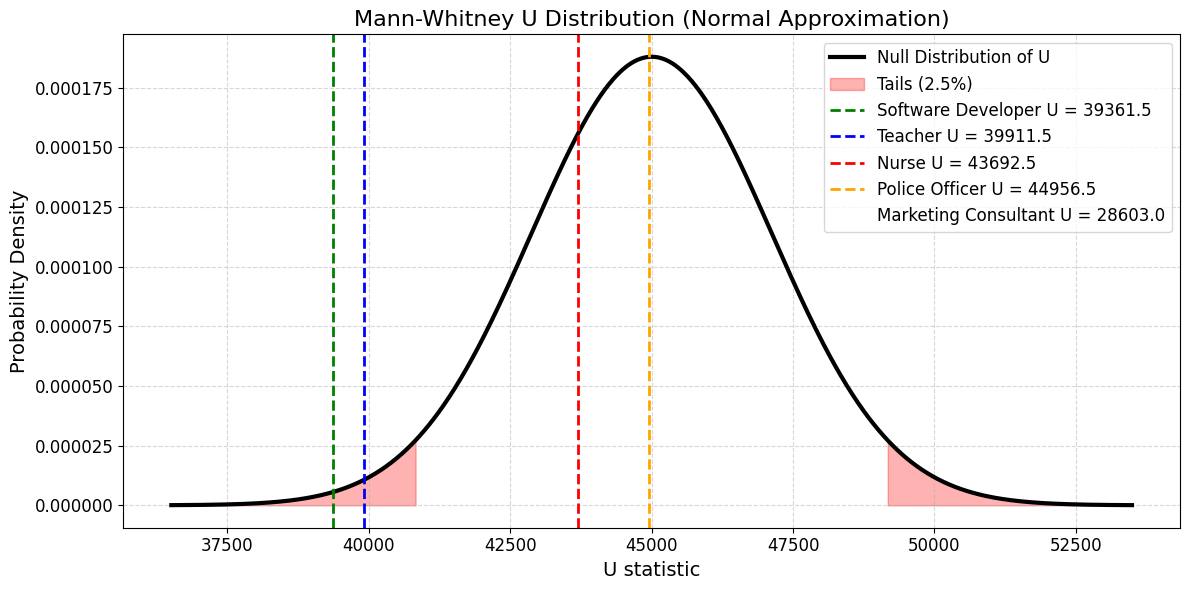

In [30]:
# Data (is found from other MW-files)
n1 = 300
n2 = 300
U_software_developer = 39361.5
U_teacher = 39911.50
U_nurse = 43692.5
U_police_officer = 44956.5
U_marketing_consultant = 28603.0

# Parameters of U under H0
mu_U = n1 * n2 / 2
sigma_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

# Critical values for 2.5% tails
lower_crit = norm.ppf(0.025, loc=mu_U, scale=sigma_U)
upper_crit = norm.ppf(0.975, loc=mu_U, scale=sigma_U)

# x values and PDF
u_vals = np.linspace(mu_U - 4*sigma_U, mu_U + 4*sigma_U, 1000)
pdf = norm.pdf(u_vals, mu_U, sigma_U)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(u_vals, pdf, color='black', lw=3, label='Null Distribution of U')

# Shade the tails
plt.fill_between(u_vals, 0, pdf, where=(u_vals < lower_crit), color='red', alpha=0.3, label='Tails (2.5%)')
plt.fill_between(u_vals, 0, pdf, where=(u_vals > upper_crit), color='red', alpha=0.3)

# Observed Us
plt.axvline(U_software_developer, color='green', linestyle='--', lw=2, label=f'Software Developer U = {U_software_developer}')
plt.axvline(U_teacher, color='blue', linestyle='--', lw=2, label=f'Teacher U = {U_teacher}')
plt.axvline(U_nurse, color='red', linestyle='--', lw=2, label=f'Nurse U = {U_nurse}')
plt.axvline(U_police_officer, color='orange', linestyle='--', lw=2, label=f'Police Officer U = {U_police_officer}')

# Labels and annotations
plt.title('Mann-Whitney U Distribution (Normal Approximation)', fontsize=16)
plt.xlabel('U statistic', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)


# Tweak ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

import matplotlib.patches as mpatches
# Create a dummy patch (no line shown) for the legend only
mc_patch = mpatches.Patch(color='white', label=f'Marketing Consultant U = {U_marketing_consultant}')
plt.legend(handles=plt.gca().get_legend_handles_labels()[0] + [mc_patch], fontsize=12)


plt.show()
